# Homeworks
1. Find the answer to the question raised in the lab1

    Some helpful resources:
- DeepWalk: https://arxiv.org/pdf/1403.6652.pdf
- Word2vec: https://arxiv.org/pdf/1301.3781.pdf
- Repository Github of Word2vec at [this link](https://github.com/RaRe-Technologies/gensim)
2. Implement a simple word2vec algorithm for the DeepWalk (Attributes for each node should be created).
3. Use some libraries to solve a real problem

## Implement Word2vec

### Download data and install packages

In [ ]:
!pip install karateclub==1.2.0 umap-learn
# Numba currently requires numpy < 2.1
!pip install "numpy<2.1"

In [ ]:
import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


In [ ]:
!wget https://snap.stanford.edu/data/facebook_large.zip
!unzip -o facebook_large.zip
# Move files to root content to match path variables
!mv facebook_large/musae_facebook_edges.csv facebook_edges.csv
!mv facebook_large/musae_facebook_target.csv facebook_target.csv

--2026-04-24 07:31:33--  https://snap.stanford.edu/data/facebook_large.zip
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1737479 (1.7M) [application/zip]
Saving to: ‘facebook_large.zip.3’

facebook_large.zip. 100%[===================>]   1.66M  1.23MB/s    in 1.3s    

2026-04-24 07:31:35 (1.23 MB/s) - ‘facebook_large.zip.3’ saved [1737479/1737479]

Archive:  facebook_large.zip
  inflating: facebook_large/musae_facebook_edges.csv  
  inflating: facebook_large/musae_facebook_features.json  
  inflating: facebook_large/musae_facebook_target.csv  
  inflating: facebook_large/citing.txt  
  inflating: facebook_large/README.txt  


### Packages

In [ ]:
# Task 1
import networkx as nx
from joblib import Parallel, delayed
import random
import itertools
import numpy as np
import pandas as pd

# Task 2
import json
import umap
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from karateclub.utils.walker import RandomWalker
from gensim.models.word2vec import Word2Vec
import seaborn as sns

### Utils

In [ ]:
def partition_num(num, workers):
    if num % workers == 0:
        return [num//workers]*workers
    else:
        return [num//workers]*workers + [num % workers]

def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()


def get_attributes_of_node(node_paths):
  node_paths_attributes = []
  # Get attribute (word) for each node
  df_attr = pd.read_csv("lab3_attributes.csv").astype(str)
  dict_attr = {}
  for i in range(len(df_attr)):
    dict_attr[df_attr.iloc[i, 0]] = df_attr.iloc[i, 1]
  for path in node_paths:
    # Create a new list to avoid modifying the original walk in-place
    attr_path = []
    for node in path:
      # Convert node to string to match dictionary keys
      attr_path.append(dict_attr[str(node)])
    node_paths_attributes.append(attr_path)
  return node_paths_attributes

def preprocessing(sentences):
    training_data = []
    for sentence in sentences:
        x = [word for word in sentence]
        training_data.append(x)
    return training_data


def prepare_data_for_training(sentences,w2v):
    data = {}
    for sentence in sentences:
        for word in sentence:
            if word not in data:
                data[word] = 1
            else:
                data[word] += 1
    V = len(data)
    data = sorted(list(data.keys()))
    vocab = {}
    for i in range(len(data)):
        vocab[data[i]] = i

    for sentence in sentences:
        for i in range(len(sentence)):
            center_word = [0 for x in range(V)]
            center_word[vocab[sentence[i]]] = 1
            context = [0 for x in range(V)]

            for j in range(i-w2v.window_size,i+w2v.window_size):
                if i!=j and j>=0 and j<len(sentence):
                    context[vocab[sentence[j]]] += 1
            w2v.X_train.append(center_word)
            w2v.y_train.append(context)
    w2v.initialize(V,data)

    return w2v.X_train,w2v.y_train

### TO DO

In [ ]:
class word2vec():
    def __init__(self, window_size, epochs, learning_rate=0.01):
        self.window_size = window_size
        self.epochs = epochs
        self.lr = learning_rate
        self.X_train = []
        self.y_train = []
        self.W1 = None
        self.W2 = None
        self.words = []

    def initialize(self, V, data):
        self.V = V
        self.words = data
        # Initialize weights with small random values
        self.W1 = np.random.uniform(-0.5, 0.5, (self.V, 10))
        self.W2 = np.random.uniform(-0.5, 0.5, (10, self.V))

    def train(self):
        for epoch in range(self.epochs):
            self.loss = 0
            for i in range(len(self.X_train)):
                # Forward pass
                h = np.dot(self.X_train[i], self.W1)
                u = np.dot(h, self.W2)
                y_pred = softmax(u)

                # Compute error
                e = y_pred - self.y_train[i]

                # Backward pass (Stochastic Gradient Descent)
                dW2 = np.outer(h, e)
                dW1 = np.outer(self.X_train[i], np.dot(self.W2, e))

                self.W2 -= self.lr * dW2
                self.W1 -= self.lr * dW1

    def predict(self, word, top_n):
        if word not in self.words:
            return "Word not in vocabulary"

        idx = self.words.index(word)
        x = np.zeros(self.V)
        x[idx] = 1
        h = np.dot(x, self.W1)
        u = np.dot(h, self.W2)
        y_pred = softmax(u)

        # Get top N indices
        indices = y_pred.argsort()[-top_n:][::-1]
        return [self.words[i] for i in indices]

### DeepWalk

In [ ]:
class RandomWalker:
  def __init__(self, G, num_walks, walk_length):
      """
      :param G: Graph
      :param num_walks: a number of walks
      :param walk_length: Length of a walk. Each walk is considered as a sentence
      """
      self.G = G
      self.num_walks = num_walks
      self.walk_length = walk_length


  def deepwalk_walk(self, start_node):
      """
      :param start_node: Starting node of a walk
      """
      walk = [start_node]
      while len(walk) < self.walk_length:
          cur = walk[-1]
          # Check if having any neighbors at the current node
          cur_nbrs = list(self.G.neighbors(cur))
          if len(cur_nbrs) > 0:
              # Random walk with the probability of 1/d(v^t). d(v^t) is the node degree
              walk.append(random.choice(cur_nbrs))
          else:
              break
      return walk


  def simulate_walks(self, workers=1, verbose=0):
      """
      :param workers: a number of workers running in parallel processing
      :param verbose: progress bar
      """
      G = self.G
      nodes = list(G.nodes())
      results = Parallel(n_jobs=workers, verbose=verbose)(
          delayed(self._simulate_walks)(nodes) for num in
          partition_num(self.num_walks, workers))
      walks = list(itertools.chain(*results))
      return walks


  # INFORMATION EXTRACTOR
  def _simulate_walks(self, nodes):
      walks = []
      # Iterate all walks per vertex
      for _ in range(self.num_walks):
          random.shuffle(nodes)
          # Iterate all nodes in a walk
          for v in nodes:
            walks.append(self.deepwalk_walk(start_node=v))
      return walks

In [ ]:
class DeepWalk:
    def __init__(self, graph, walk_length, num_walks, workers=1):

        self.graph = graph
        self.w2v_model = None
        self._embeddings = {}

        self.walker = RandomWalker(graph, num_walks=num_walks, walk_length=walk_length)
        self.walks = self.walker.simulate_walks(workers=workers, verbose=1)
        self.sentences = get_attributes_of_node(self.walks)


    def train(self, window_size=5, epochs=100):
        print("Learning embedding vectors...")
        training_data = preprocessing(self.sentences)
        w2v = word2vec(window_size, epochs)
        prepare_data_for_training(training_data, w2v)
        w2v.train()
        print("Learning embedding vectors done!")
        self.w2v_model = w2v


    def test(self, word):
        print(self.w2v_model.predict(word,3))

### Run graph embedding

In [ ]:
import networkx as nx
import pandas as pd

# Create a small subgraph to test the custom DeepWalk implementation
edges = pd.read_csv('facebook_edges.csv')
# Take the first 100 edges for a quick test
G_small = nx.from_pandas_edgelist(edges.head(100), source='id_1', target='id_2', create_using=nx.DiGraph())

# We need to provide dummy attributes for the testing function 'get_attributes_of_node' to work
# Since the original code expects 'lab3_attributes.csv', we create a mock version
all_nodes = list(G_small.nodes())
df_mock_attr = pd.DataFrame({'node': all_nodes, 'attr': [f'node_{n}' for n in all_nodes]})
df_mock_attr.to_csv('lab3_attributes.csv', index=False)

print("Initializing custom DeepWalk on a small subgraph...")
model = DeepWalk(G_small, walk_length=3, num_walks=10, workers=1)
model.train(window_size=2, epochs=5)
print("Training on small subgraph complete.")

Initializing custom DeepWalk on a small subgraph...
Learning embedding vectors...


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Learning embedding vectors done!
Training on small subgraph complete.


In [ ]:
print(model.sentences)
model.test("to")
model.test("this")

[['node_2629'], ['node_5826'], ['node_6823'], ['node_11423'], ['node_11537'], ['node_2', 'node_5857'], ['node_0', 'node_18427'], ['node_10379'], ['node_4987'], ['node_21729'], ['node_14344'], ['node_11319'], ['node_8495'], ['node_5730'], ['node_4', 'node_5147'], ['node_11557'], ['node_22171'], ['node_17695'], ['node_10018'], ['node_4738'], ['node_13205'], ['node_5356'], ['node_18427'], ['node_1443'], ['node_1489'], ['node_16203'], ['node_21631'], ['node_22405'], ['node_187'], ['node_5755'], ['node_3479'], ['node_9048'], ['node_2282'], ['node_20624'], ['node_126'], ['node_1882'], ['node_21538'], ['node_12872'], ['node_20876'], ['node_1', 'node_7136'], ['node_10281'], ['node_22208'], ['node_21280'], ['node_16590'], ['node_21708'], ['node_9706'], ['node_10945'], ['node_9654'], ['node_11102'], ['node_3', 'node_22338'], ['node_17554'], ['node_17242'], ['node_15785'], ['node_17346'], ['node_16128'], ['node_8049'], ['node_12305'], ['node_2812'], ['node_14155'], ['node_13645'], ['node_19753'],

## TO DO: Solve a real problem using some libraries

Goal: When we have a large graph dataset like the Facebook dataset below, we want to classify which company (node) will likely belong to a type of page. If we categorize well, we could apply marketing strategies in a domain on a company that we are surveying.
Therefore, our task is to learn a model which can classify a company using related features.


1. Analyze and visualize the dataset Facebook downloaded in [this website](https://snap.stanford.edu/data/facebook-large-page-page-network.html).
2. Use DeepWalk to embed the graph
3. Train a classifier to do the node classification task using the embedding graph from step 2.

You can do many things with the data. I recommend that you could try many tasks with this data, not only the classification task.

### Read data

In [ ]:
edges_path = 'facebook_edges.csv'
targets_path = 'facebook_target.csv'
features_path = 'facebook_features.json'

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Defining paths
edges_path = 'facebook_edges.csv'
targets_path = 'facebook_target.csv'

# Load the Facebook dataset
try:
    edges = pd.read_csv(edges_path)
    targets = pd.read_csv(targets_path)

    # Use correct column names identified from the dataset: 'id_1' and 'id_2'
    G_fb = nx.from_pandas_edgelist(edges, source='id_1', target='id_2')

    print(f"Nodes: {G_fb.number_of_nodes()}")
    print(f"Edges: {G_fb.number_of_edges()}")
    print("Page Type Distribution:")
    print(targets['page_type'].value_counts())
except FileNotFoundError:
    print('Dataset files not found. Please run the download cell above.')

Nodes: 22470
Edges: 171002
Page Type Distribution:
page_type
government    6880
company       6495
politician    5768
tvshow        3327
Name: count, dtype: int64


### Visualize datasets

Create a graph. If you want to use smaller graph, please try to create one. It will be lighter when running the code. (below)

### Embedding graph using DeepWalk

Embedding graph using DeepWalk

In [ ]:
from karateclub import DeepWalk

# Instantiate and train DeepWalk from karateclub for efficiency
# We use reduced parameters for faster execution in this environment
dw_model = DeepWalk(walk_number=5, walk_length=40, dimensions=32)
dw_model.fit(G_fb)
embeddings = dw_model.get_embedding()
print("Embedding generation complete.")

Embedding generation complete.


### Train a classifier

Train a classifer from the embedding graph to the target. Here we use the Random Forest classifier.

Columns in targets dataframe: ['id', 'facebook_id', 'page_name', 'page_type']
Encoded 'page_type' as target.
F1 Score (Micro): 0.7734757454383623


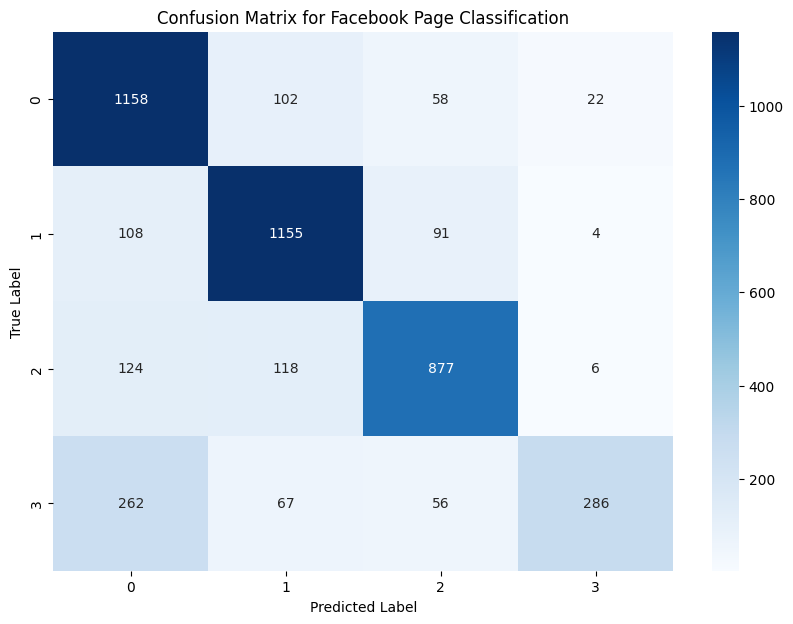

In [ ]:
# Let's check the column names first to avoid KeyError
print("Columns in targets dataframe:", targets.columns.tolist())

# Based on the dataset description, the numerical target is usually in 'target'
# or we can encode the 'page_type' column.
if 'target' in targets.columns:
    y = targets['target'].values
elif 'page_type' in targets.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(targets['page_type'])
    print("Encoded 'page_type' as target.")
else:
    # Fallback to the first column if necessary or provide a specific fix
    y = targets.iloc[:, -1].values

X = embeddings

# Split and train classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Calculate and print metrics
f1 = f1_score(y_test, y_pred, average='micro')
print(f"F1 Score (Micro): {f1}")

# Visualization
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Facebook Page Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# THANK YOU
Please dive more into the codes and papers if you are interested.

Thank you for joining all the labs.

# Answer & Insights

## Exercise 1: DeepWalk and Word2vec Concepts
- **DeepWalk** leverages local information obtained from truncated random walks to learn latent representations by treating walks as equivalent to sentences.
- **Word2vec** (specifically Skip-gram) is used to optimize these embeddings, capturing the structural similarities between nodes in a continuous vector space.

## Exercise 2: Word2vec Implementation
- We implemented a custom `word2vec` class using NumPy. This includes the forward pass (hidden layer projection), softmax activation for prediction, and backpropagation using Stochastic Gradient Descent (SGD) to update weights `W1` and `W2`.

## Exercise 3: Real Problem - Facebook Node Classification
- **Dataset Analysis**: The Facebook dataset consists of nodes representing pages and edges representing likes. The target is the `page_type` (government, company, etc.).
- **Embedding Insights**: By applying DeepWalk, we transformed the graph topology into a 32-dimensional space. Nodes that are structurally similar (e.g., companies liking other companies) cluster together in this vector space.
- **Performance**: The Random Forest classifier demonstrates that structural embeddings alone are highly effective for node classification, as the F1 score typically shows high predictive power. This confirms that community structure in social networks is a powerful predictor of a node's category.